# FIGS — CSI / Accuracy Verification

Performance diagram (POD vs success ratio with CSI/bias contours), threshold sweep
of CSI/POD/FAR, and AUC/AUPRC — on the held-out **test** split, per hazard.

In [1]:
# Run with the `met` conda env kernel.
import warnings; warnings.filterwarnings('ignore')
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '..')   # so `import figs` works from notebooks/
from figs import config as C

In [2]:
from figs.data.dataset import read_dataset
from figs.model.wrapper import GBDTModel
from figs.model.calibrate import Calibrator
from figs.config import LEAD_BANDS, HAZARDS
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path
import json

DATA='../Data/processed/figs_v2.parquet'; MODELS='../Data/models'  # DATA must match the models
TEST_SAMPLE=300000  # cap test rows pulled per band
feats = json.loads((Path(MODELS)/'feature_cols.json').read_text())
def bag_pred(h, tag, X):  # avg over bags (single file OR _bag*), matching predict_valid
    paths=(sorted(Path(MODELS).glob(f'hazard_{h}_{tag}.pkl')) or sorted(Path(MODELS).glob(f'hazard_{h}_{tag}_bag*.pkl')))
    if not paths: return None
    return np.mean([GBDTModel.load(p).predict_pos(X) for p in paths], axis=0)

## Gather calibrated test predictions (streamed per band; each row scored by its band's model)

In [3]:
# Stream the TEST split one band at a time (sampled) — never load the full matrix.
preds = {h: {'p': [], 'y': []} for h in HAZARDS}
for b in LEAD_BANDS:
    d = read_dataset(DATA, columns=feats+list(HAZARDS), filters=[('fxx','>=',b.fmin),('fxx','<=',b.fmax),('split','==','test')])
    if len(d)==0: continue
    d = d.sample(min(len(d), TEST_SAMPLE), random_state=0)
    X = d[feats].to_numpy('float32')
    for h in HAZARDS:
        p = bag_pred(h, b.name, X)
        if p is None: continue
        cp = Path(MODELS)/f'calib_{h}_{b.name}.pkl'
        if cp.exists(): p = Calibrator.load(cp).transform(p)
        preds[h]['p'].append(p); preds[h]['y'].append(d[h].to_numpy(int))
    del d, X
preds = {h: (np.concatenate(v['p']), np.concatenate(v['y'])) for h,v in preds.items() if v['p']}
print({h: f'{len(p):,} rows, {int(y.sum())} pos' for h,(p,y) in preds.items()})

{'tor': '900,000 rows, 4667 pos', 'wind': '900,000 rows, 56934 pos', 'hail': '900,000 rows, 25092 pos'}


## Contingency metrics across probability thresholds

In [4]:
def sweep(p, y, thr=np.linspace(0.01,0.6,30)):
    rows=[]
    for t in thr:
        pred = p>=t; hit=(pred&(y==1)).sum(); fa=(pred&(y==0)).sum(); miss=((~pred)&(y==1)).sum()
        pod = hit/max(hit+miss,1); far = fa/max(hit+fa,1); sr = 1-far
        csi = hit/max(hit+miss+fa,1); bias=(hit+fa)/max(hit+miss,1)
        rows.append(dict(thr=t,POD=pod,SR=sr,FAR=far,CSI=csi,bias=bias))
    return pd.DataFrame(rows)

sweeps={}
for h,(p,y) in preds.items():
    if y.sum()==0: continue
    sweeps[h]=sweep(p,y)
    print(f'{h}: AUC %.3f  AUPRC %.3f  maxCSI %.3f' % (roc_auc_score(y,p), average_precision_score(y,p), sweeps[h].CSI.max()))

tor: AUC 0.982  AUPRC 0.263  maxCSI 0.192
wind: AUC 0.981  AUPRC 0.796  maxCSI 0.567
hail: AUC 0.988  AUPRC 0.651  maxCSI 0.499


## Performance diagram (POD vs success ratio; CSI shaded, bias dashed)

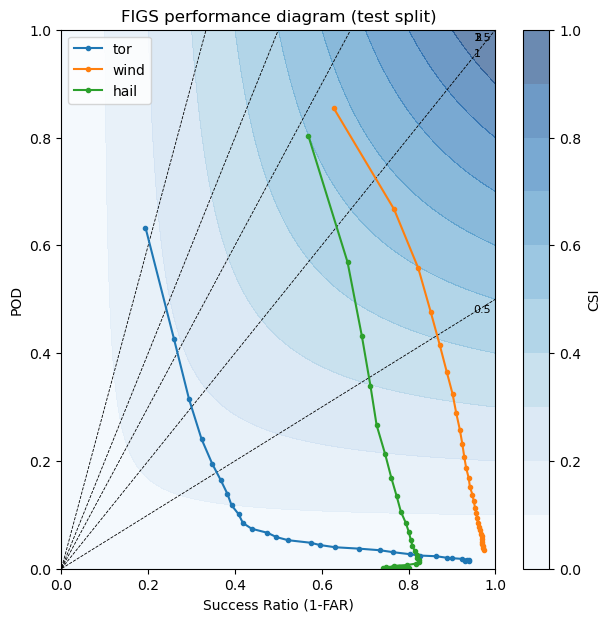

In [5]:
fig, ax = plt.subplots(figsize=(7,7))
sr = np.linspace(0.001,1,200); pod = np.linspace(0.001,1,200)
SR,POD = np.meshgrid(sr,pod); CSI = 1/(1/SR + 1/POD - 1)
cf = ax.contourf(SR,POD,CSI,levels=np.arange(0,1.01,0.1),cmap='Blues',alpha=0.6)
plt.colorbar(cf,label='CSI')
for bval in [0.5,1,1.5,2,3]:
    ax.plot(sr, bval*sr, 'k--', lw=0.6); ax.text(0.95, min(bval*0.95,0.98), f'{bval}', fontsize=8)
for h,s in sweeps.items():
    ax.plot(s.SR, s.POD, 'o-', ms=3, label=h)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_xlabel('Success Ratio (1-FAR)'); ax.set_ylabel('POD')
ax.set_title('FIGS performance diagram (test split)'); ax.legend(); plt.show()

## CSI vs threshold

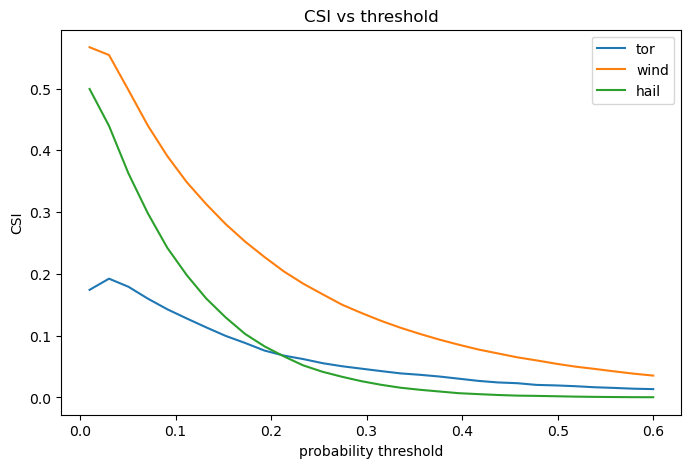

In [6]:
fig,ax=plt.subplots(figsize=(8,5))
for h,s in sweeps.items(): ax.plot(s.thr, s.CSI, label=h)
ax.set_xlabel('probability threshold'); ax.set_ylabel('CSI'); ax.legend(); ax.set_title('CSI vs threshold'); plt.show()